# Sequences quality/Filtering

## Imports

In [489]:
from Bio.SeqUtils.IsoelectricPoint import IsoelectricPoint as IEP
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import pandas as pd
import numpy as np

from Bio import pairwise2

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from Bio.SeqUtils.lcc import lcc_simp
import re

import os
import pandas as pd
import seaborn as sns

from scipy.stats import ks_2samp, mannwhitneyu, chi2_contingency, entropy
import umap

import subprocess
from Bio import SeqIO

## Files to Aggrescan

In [490]:
path_ProtGPT = './files/generated_datasets/protGPT2_generated_sequences-17709.csv'
path_CVAE = 'files/generated_datasets/CVAE_generated_sequences-11977.csv'

df_protgpt = pd.read_csv(path_ProtGPT)
df_cvae = pd.read_csv(path_CVAE)

In [491]:
print(len(df_protgpt))
print(len(df_cvae))

17709
11977


In [492]:
if "id" not in df_protgpt.columns:
    df_protgpt.insert(
        0,
        "id",
        [f"ProtGPT2_{i+1}" for i in range(len(df_protgpt))]
    )

if "id" not in df_cvae.columns:
    df_cvae.insert(
        0,
        "id",
        [f"CVAE_{i+1}" for i in range(len(df_cvae))]
    )

In [493]:
df_protgpt.head()

,id,sequence,length
0,ProtGPT2_1,LFFEDVN,7
1,ProtGPT2_2,GDRSRVFIGNV,11
2,ProtGPT2_3,VQIINNIRDITKDEVTQHFTVHNGNV,26
3,ProtGPT2_4,SFGSARAEGHGPVVQAGDIVLGGLGSLVYGQMNEPPGNRLRVALTGLTM,49
4,ProtGPT2_5,GRYSFVIQGRDFS,13


In [494]:
df_cvae.head()

,id,sequence,length
0,CVAE_1,LHFGKHLDMEMM,12
1,CVAE_2,EGKFMW,6
2,CVAE_3,LDFFW,5
3,CVAE_4,ALKGGEA,7
4,CVAE_5,EWGFTM,6


### Invalid sequences

In [495]:
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"

In [496]:
def find_invalid_sequences(df, seq_col="sequence"):
    valid = set(AMINO_ACIDS)
    invalid_rows = []

    for i, seq in df[seq_col].items():
        bad_chars = set(seq) - valid

        if len(bad_chars) > 0:
            invalid_rows.append({
                "index": i,
                "sequence": seq,
                "invalid_chars": "".join(sorted(bad_chars))
            })

    return pd.DataFrame(invalid_rows)

In [497]:
bad_df = find_invalid_sequences(df_protgpt)

print(bad_df.head())
print("Invalid sequences:", len(bad_df))

Empty DataFrame
Columns: []
Index: []
Invalid sequences: 0


In [498]:
bad_df = find_invalid_sequences(df_cvae)

print(bad_df.head())
print("Invalid sequences:", len(bad_df))

Empty DataFrame
Columns: []
Index: []
Invalid sequences: 0


In [499]:
def write_fasta(df, filename, seq_col="sequence", id_col="id"):
    with open(filename, "w") as f:
        for i, row in df.iterrows():
            sid = row.get(id_col, f"gen_{i}")
            seq = row[seq_col]
            f.write(f">{sid}\n{seq}\n")

In [500]:
write_fasta(df_protgpt, './files/generated_datasets/Aggrescan_protGPT2_generated_sequences-17709.fasta')
write_fasta(df_cvae, './files/generated_datasets/Aggrescan_CVAE_generated_sequences-11977.fasta')

## Aggrescan features

In [501]:
def aggrescan_features_extraction(path):
    agg_data = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if not (line[0].isdigit() or line[0] == '-'):
                continue

            cols = line.split()
            if len(cols) < 13:
                continue

            agg_data.append({
                "id": cols[1].replace(">", ""),
                "a3vSA": float(cols[0]),
                "AAT": float(cols[5]),
                "Na4vSS": float(cols[7]),
                "THSA": float(cols[9]),
                "nHS": int(cols[11]),
                "TA": float(cols[12]),
            })

    df_agg = pd.DataFrame(agg_data)
    return df_agg

In [502]:
agg_file_protgpt = "./files/generated_datasets/Aggrescan_protGPT2_generated_sequences-17709.out"
agg_file_cvae = "./files/generated_datasets/Aggrescan_CVAE_generated_sequences-11977.out"

df_agg_protgpt = aggrescan_features_extraction(agg_file_protgpt)
df_agg_cvae = aggrescan_features_extraction(agg_file_cvae)

In [503]:
def merge_with_agg(df_main, df_agg):
    df_agg = df_agg.drop(columns=[c for c in ["sequence", "length"] if c in df_agg.columns], errors="ignore")

    df = df_main.merge(df_agg, on="id", how="left")

    left_cols = ["id", "sequence", "length"]
    other_cols = [c for c in df.columns if c not in left_cols]

    return df[left_cols + other_cols]

In [504]:
df_protgpt = merge_with_agg(df_protgpt, df_agg_protgpt)
df_cvae = merge_with_agg(df_cvae, df_agg_cvae)

In [505]:
df_protgpt.head()

,id,sequence,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA
0,ProtGPT2_1,LFFEDVN,7,0.276,1.715,-0.060,0.000,0,-0.0783
1,ProtGPT2_2,GDRSRVFIGNV,11,-0.020,3.192,-0.072,3.192,1,-0.0885
2,ProtGPT2_3,VQIINNIRDITKDEVTQHFTVHNGNV,26,-0.099,3.342,-0.167,0.000,0,-3.8085
3,ProtGPT2_4,SFGSARAEGHGPVVQAGDIVLGGLGSLVYGQMNEPPGNRLRVALTGLTM,49,0.013,10.138,-0.024,9.126,3,-0.1766
4,ProtGPT2_5,GRYSFVIQGRDFS,13,0.068,3.582,-0.022,3.582,1,0.4799


In [506]:
df_cvae.head()

,id,sequence,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA
0,CVAE_1,LHFGKHLDMEMM,12,0.039,0.459,-0.120,0.000,0,-1.2335
1,CVAE_2,EGKFMW,6,0.137,1.181,-0.004,0.000,0,0.1853
2,CVAE_3,LDFFW,5,0.818,2.291,0.408,2.291,1,1.8134
3,CVAE_4,ALKGGEA,7,-0.301,0.000,-0.481,0.000,0,-2.7125
4,CVAE_5,EWGFTM,6,0.266,1.172,0.130,0.000,0,0.8699


## Rest features extraction

In [507]:
hydro_scale = {
    'A': 1.8, 'C': 2.5, 'D': -3.5, 'E': -3.5, 'F': 2.8, 'G': -0.4, 'H': -3.2, 'I': 4.5,
    'K': -3.9, 'L': 3.8, 'M': 1.9, 'N': -3.5, 'P': -1.6, 'Q': -3.5, 'R': -4.5, 'S': -0.8,
    'T': -0.7, 'V': 4.2, 'W': -0.9, 'Y': -1.3
}

beta_prop = {
    'A': 0.83, 'C': 1.19, 'D': 0.54, 'E': 0.37, 'F': 1.38, 'G': 0.75, 'H': 0.87, 'I': 1.60,
    'K': 0.74, 'L': 1.30, 'M': 1.05, 'N': 0.89, 'P': 0.55, 'Q': 1.10, 'R': 0.93, 'S': 0.75,
    'T': 1.19, 'V': 1.70, 'W': 1.37, 'Y': 1.47
}

valid_aas = set("ACDEFGHIKLMNPQRSTVWY")

def clean_sequence(seq):
    seq = seq.upper().strip()
    seq = "".join([a for a in seq if a in valid_aas])
    return seq


def seq_entropy(seq):
    from collections import Counter
    c = Counter(seq)
    L = len(seq)
    return -sum((v / L) * np.log2(v / L) for v in c.values())


def net_charge(seq):
    return seq.count('K') + seq.count('R') - seq.count('D') - seq.count('E') + 0.1 * seq.count('H')

def aa_fraction(seq, group):
    aa_groups = {
        "polar": "NQSTY",
        "nonpolar": "ACFGILMPVW",
        "acidic": "DE",
        "basic": "HKR",
    }
    return sum(seq.count(a) for a in aa_groups[group]) / len(seq) if len(seq) > 0 else 0


def compute_features(seq):
    seq = clean_sequence(seq)
    seq = seq.upper().strip()
    L = len(seq)

    pa = ProteinAnalysis(seq)
    iep = IEP(seq).pi()


    return {
        "length": L,
        "entropy": seq_entropy(seq),
        "hydrophobicity": sum(hydro_scale[a] for a in seq) / L,
        "net_charge": net_charge(seq),
        "beta_propensity": sum(beta_prop[a] for a in seq) / L,
        "aromatic_fraction": sum(seq.count(a) for a in "FYW") / L,
        "proline_fraction": seq.count("P") / L,
        "pI": iep,
        "gravy": pa.gravy(),
        "instability_index": pa.instability_index(),
        "polar_fraction": aa_fraction(seq, "polar"),
        "nonpolar_fraction": aa_fraction(seq, "nonpolar"),
        "acidic_fraction": aa_fraction(seq, "acidic"),
        "basic_fraction": aa_fraction(seq, "basic"),
    }

In [508]:
def add_features(df, seq_col="sequence"):
    feats = df[seq_col].apply(compute_features)
    return pd.concat([df.reset_index(drop=True), pd.DataFrame(list(feats))], axis=1)

In [509]:
df_protgpt = add_features(df_protgpt)
df_cvae = add_features(df_cvae)

In [510]:
df_protgpt.head()

,id,sequence,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA,length,...,beta_propensity,aromatic_fraction,proline_fraction,pI,gravy,instability_index,polar_fraction,nonpolar_fraction,acidic_fraction,basic_fraction
0,ProtGPT2_1,LFFEDVN,7,0.276,1.715,-0.060,0.000,0,-0.0783,7,...,1.080000,0.285714,0.000000,4.050028,0.442857,36.085714,0.142857,0.571429,0.285714,0.000000
1,ProtGPT2_2,GDRSRVFIGNV,11,-0.020,3.192,-0.072,3.192,1,-0.0885,11,...,1.083636,0.090909,0.000000,9.598714,-0.172727,51.972727,0.181818,0.545455,0.090909,0.181818
2,ProtGPT2_3,VQIINNIRDITKDEVTQHFTVHNGNV,26,-0.099,3.342,-0.167,0.000,0,-3.8085,26,...,1.135385,0.038462,0.000000,5.996252,-0.430769,16.423077,0.346154,0.384615,0.115385,0.153846
3,ProtGPT2_4,SFGSARAEGHGPVVQAGDIVLGGLGSLVYGQMNEPPGNRLRVALTGLTM,49,0.013,10.138,-0.024,9.126,3,-0.1766,49,...,0.997347,0.040816,0.061224,6.481544,0.142857,17.451020,0.204082,0.653061,0.061224,0.081633
4,ProtGPT2_5,GRYSFVIQGRDFS,13,0.068,3.582,-0.022,3.582,1,0.4799,13,...,1.079231,0.230769,0.000000,8.745346,-0.415385,-2.369231,0.307692,0.461538,0.076923,0.153846


In [511]:
df_cvae.head()

,id,sequence,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA,length,...,beta_propensity,aromatic_fraction,proline_fraction,pI,gravy,instability_index,polar_fraction,nonpolar_fraction,acidic_fraction,basic_fraction
0,CVAE_1,LHFGKHLDMEMM,12,0.039,0.459,-0.120,0.000,0,-1.2335,12,...,0.939167,0.083333,0.0,5.991080,-0.133333,-8.950000,0.000000,0.583333,0.166667,0.250000
1,CVAE_2,EGKFMW,6,0.137,1.181,-0.004,0.000,0,0.1853,6,...,0.943333,0.333333,0.0,6.100722,-0.666667,-5.816667,0.000000,0.666667,0.166667,0.166667
2,CVAE_3,LDFFW,5,0.818,2.291,0.408,2.291,1,1.8134,5,...,1.194000,0.600000,0.0,4.050028,1.000000,-7.080000,0.000000,0.800000,0.200000,0.000000
3,CVAE_4,ALKGGEA,7,-0.301,0.000,-0.481,0.000,0,-2.7125,7,...,0.795714,0.000000,0.0,6.046100,-0.114286,-8.828571,0.000000,0.714286,0.142857,0.142857
4,CVAE_5,EWGFTM,6,0.266,1.172,0.130,0.000,0,0.8699,6,...,1.018333,0.333333,0.0,4.050028,-0.133333,-34.000000,0.166667,0.666667,0.166667,0.000000


In [512]:
df_protgpt.describe()

,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA,length,entropy,hydrophobicity,...,beta_propensity,aromatic_fraction,proline_fraction,pI,gravy,instability_index,polar_fraction,nonpolar_fraction,acidic_fraction,basic_fraction
count,17709.000000,17709.000000,17709.000000,17709.000000,17709.000000,17709.000000,17709.000000,17709.000000,17709.000000,17709.000000,...,17709.000000,17709.000000,17709.000000,17709.000000,17709.000000,17709.000000,17709.000000,17709.000000,17709.000000,17709.000000
mean,21.637755,-0.170435,1.735222,-0.226024,0.934916,0.406912,-4.773413,21.637755,3.071602,-0.469301,...,1.031064,0.077603,0.008134,5.828115,-0.469301,14.691366,0.389643,0.464941,0.068122,0.077294
std,13.089519,0.253501,1.737763,0.225534,1.683913,0.578285,5.702351,13.089519,0.386133,0.673858,...,0.071910,0.079695,0.022622,1.558533,0.673858,25.551058,0.146653,0.132922,0.056268,0.064805
min,5.000000,-1.060000,0.000000,-1.074000,0.000000,0.000000,-76.925804,5.000000,0.940182,-3.059574,...,0.707143,0.000000,0.000000,4.050028,-3.059574,-67.200000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,-0.325000,0.489000,-0.361000,0.000000,0.000000,-7.141600,14.000000,2.855389,-0.896875,...,0.988095,0.000000,0.000000,4.658717,-0.896875,-2.330769,0.285714,0.375000,0.000000,0.000000
50%,19.000000,-0.209000,1.267000,-0.252000,0.000000,0.000000,-4.052201,19.000000,3.131933,-0.533333,...,1.025000,0.062500,0.000000,5.524318,-0.533333,12.027273,0.384615,0.454545,0.066667,0.071429
75%,26.000000,-0.066000,2.439000,-0.123000,1.526000,1.000000,-1.370300,26.000000,3.349693,-0.115000,...,1.065429,0.111111,0.000000,6.614490,-0.115000,28.925000,0.487179,0.545455,0.105263,0.117647
max,152.000000,1.425000,36.538000,1.137000,34.063000,4.000000,34.254929,152.000000,4.029113,3.500000,...,1.514000,0.500000,0.250000,11.999968,3.500000,168.557143,1.000000,1.000000,0.400000,0.428571


In [513]:
df_cvae.describe()

,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA,length,entropy,hydrophobicity,...,beta_propensity,aromatic_fraction,proline_fraction,pI,gravy,instability_index,polar_fraction,nonpolar_fraction,acidic_fraction,basic_fraction
count,11977.000000,11977.000000,11977.000000,11977.000000,11977.000000,11977.000000,11977.000000,11977.000000,11977.000000,11977.000000,...,11977.000000,11977.000000,11977.000000,11977.000000,11977.000000,11977.000000,11977.000000,11977.000000,11977.000000,11977.000000
mean,6.732821,0.144771,1.385277,-0.033143,0.797024,0.219087,-0.122866,6.732821,2.335978,-0.328744,...,1.031712,0.201346,0.082557,6.415660,-0.328744,30.035471,0.243287,0.534789,0.097479,0.124445
std,3.223875,0.563430,1.939111,0.490999,1.880922,0.423618,3.396979,3.223875,0.340981,1.334824,...,0.187531,0.148445,0.097527,2.114903,1.334824,42.360019,0.238647,0.231373,0.123332,0.161810
min,5.000000,-1.379000,0.000000,-1.378000,0.000000,0.000000,-43.464703,5.000000,-0.000000,-4.200000,...,0.514000,0.000000,0.000000,4.050028,-4.200000,-84.180000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,-0.280000,0.000000,-0.396000,0.000000,0.000000,-1.877700,5.000000,2.235926,-1.300000,...,0.891667,0.111111,0.000000,4.856574,-1.300000,-1.862500,0.000000,0.400000,0.000000,0.000000
50%,6.000000,0.132000,0.595000,-0.033000,0.000000,0.000000,0.020400,6.000000,2.321928,-0.400000,...,1.023333,0.200000,0.000000,5.525000,-0.400000,26.200000,0.200000,0.571429,0.000000,0.076923
75%,7.000000,0.558000,2.172000,0.332000,0.000000,0.000000,1.864300,7.000000,2.584963,0.600000,...,1.168000,0.300000,0.166667,8.589977,0.600000,53.941000,0.400000,0.666667,0.200000,0.200000
max,50.000000,1.717000,37.085000,1.291000,37.085000,4.000000,37.943604,50.000000,3.664498,4.160000,...,1.596000,0.800000,0.600000,11.999968,4.160000,310.160000,1.000000,1.000000,0.666667,1.000000


## Reference dataset

In [514]:
ref_path = "files/df_ml_good_with_features.csv"
df_ref = pd.read_csv(ref_path)
print(len(df_ref))

df_ref = df_ref[df_ref['class'] == 1]
print(len(df_ref))

1934
1006


## Low-complexity filtering (SEG/LCC)

In [515]:
def low_complexity_score(seq):
    return lcc_simp(seq)

In [516]:
df_ref["lcc"] = df_ref["sequence"].apply(low_complexity_score)

In [517]:
df_protgpt["lcc"] = df_protgpt["sequence"].apply(low_complexity_score)
df_cvae["lcc"] = df_cvae["sequence"].apply(low_complexity_score)

In [518]:
print("REFERENCE")
print(df_ref["lcc"].describe())

print("\nCVAE")
print(df_cvae["lcc"].describe())

print("\nProtGPT")
print(df_protgpt["lcc"].describe())

REFERENCE
count    1006.000000
mean        0.360372
std         0.163138
min         0.000000
25%         0.250000
50%         0.398289
75%         0.477496
max         0.730119
Name: lcc, dtype: float64

CVAE
count    11977.000000
mean         0.214405
std          0.149776
min          0.000000
25%          0.166096
50%          0.232193
75%          0.264160
max          0.728771
Name: lcc, dtype: float64

ProtGPT
count    17709.000000
mean         0.422808
std          0.127221
min          0.000000
25%          0.353621
50%          0.437251
75%          0.511505
max          0.774581
Name: lcc, dtype: float64


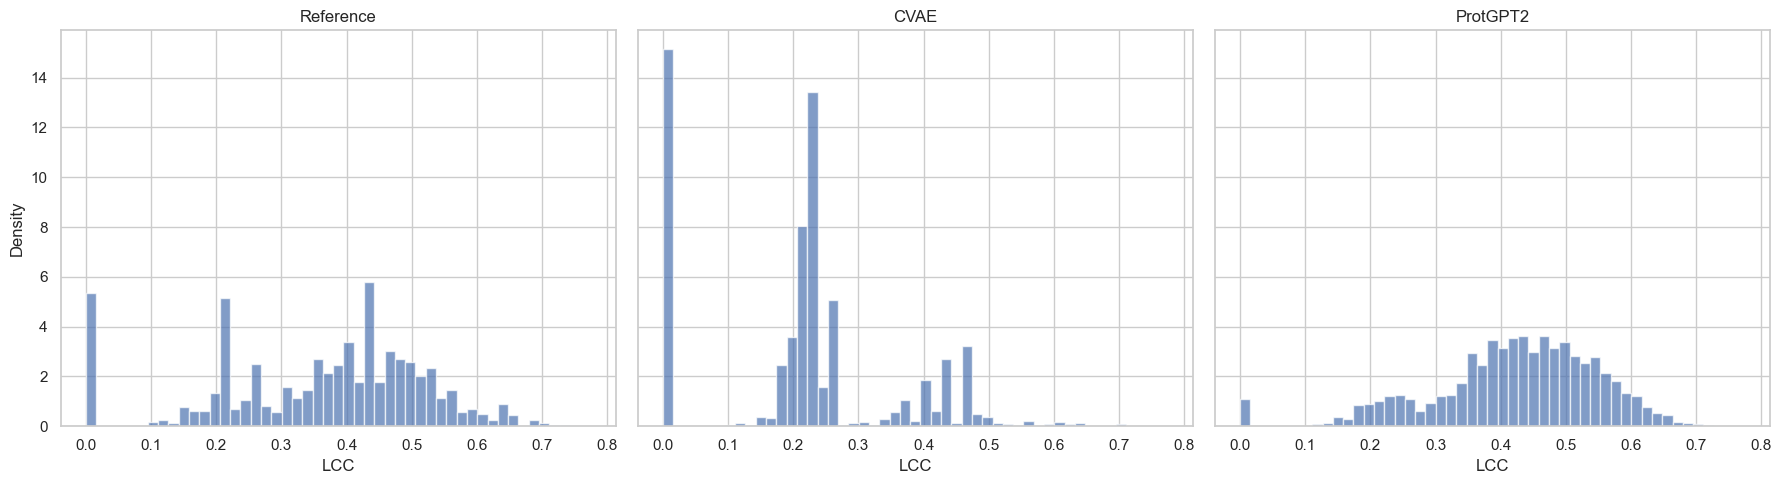

In [519]:
bins = np.linspace(
    min(
        df_ref["lcc"].min(),
        df_cvae["lcc"].min(),
        df_protgpt["lcc"].min()
    ),
    max(
        df_ref["lcc"].max(),
        df_cvae["lcc"].max(),
        df_protgpt["lcc"].max()
    ),
    50
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# ================= REF =================
axes[0].hist(
    df_ref["lcc"],
    bins=bins,
    density=True,
    alpha=0.7
)

axes[0].set_title("Reference")
axes[0].set_xlabel("LCC")
axes[0].set_ylabel("Density")

# ================= CVAE =================
axes[1].hist(
    df_cvae["lcc"],
    bins=bins,
    density=True,
    alpha=0.7
)

axes[1].set_title("CVAE")
axes[1].set_xlabel("LCC")

# ================= PROTGPT =================
axes[2].hist(
    df_protgpt["lcc"],
    bins=bins,
    density=True,
    alpha=0.7
)

axes[2].set_title("ProtGPT2")
axes[2].set_xlabel("LCC")


plt.tight_layout()
plt.savefig(
    "./files/plots/lcc_distribution_comparison.svg",
    format="svg",
    bbox_inches="tight"
)
plt.show()

In [520]:
#cutoff = df_ref["lcc"].quantile(0.005)

In [521]:
#df_cvae = df_cvae[
#    df_cvae["lcc"] > cutoff
#].copy()

#df_protgpt = df_protgpt[
#    df_protgpt["lcc"] > cutoff
#].copy()

In [522]:
print(len(df_cvae))
print(len(df_protgpt))

11977
17709


## Repetition filtering

In [523]:
def has_bad_repeats(seq):

    # >=4 tych samych AA pod rząd
    if re.search(r"(.)\1{3,}", seq):
        return True

    # powtarzający się 2-AA motif - token loop
    if re.search(r"(.{2})\1{3,}", seq):
        return True

    return False

In [524]:
print("CVAE bad repeats:", df_cvae["sequence"].apply(has_bad_repeats).sum())
print("GPT bad repeats:", df_protgpt["sequence"].apply(has_bad_repeats).sum())

CVAE bad repeats: 104
GPT bad repeats: 1210


In [525]:
df_cvae = df_cvae[
    ~df_cvae["sequence"].apply(has_bad_repeats)
].copy()

df_protgpt = df_protgpt[
    ~df_protgpt["sequence"].apply(has_bad_repeats)
].copy()

In [526]:
print(len(df_cvae))
print(len(df_protgpt))

11873
16499


## Scoring against reference amyloids

In [527]:
def score_vs_amyloids(df_gen_feat, df_amy_ref_feat, feature_cols, z_cutoff=2.25):
    df_scored = df_gen_feat.copy()

    df_scored = df_scored.drop(columns=[c for c in df_scored.columns if c.endswith("_z")], errors="ignore")

    z_abs_vals = []

    for c in feature_cols:
        # bierzemy skalar
        mu = df_amy_ref_feat[c].mean()
        sd = df_amy_ref_feat[c].std()

        if sd == 0 or np.isnan(sd):
            z = (df_scored[c] - mu) * 0.0
        else:
            z = (df_scored[c] - mu) / sd

        df_scored[c + "_z"] = z
        z_abs_vals.append(z.abs())

    z_abs_stack = np.vstack([z.values for z in z_abs_vals])

    score = z_abs_stack.mean(axis=0)
    length_penalty = np.log1p(df_scored["length"].iloc[:, 0].values)
    df_scored["amyloid_likeness_score_norm"] = score / length_penalty
    df_scored["flag_outlier"] = (z_abs_stack > z_cutoff).any(axis=0)

    return df_scored

In [528]:
features = ['beta_propensity', 'proline_fraction', 'AAT', 'net_charge', 'TA', 'polar_fraction', 'a3vSA']

df_gen_scored_protgpt = score_vs_amyloids(df_protgpt, df_ref, features)
df_gen_scored_cvae = score_vs_amyloids(df_cvae, df_ref, features)

In [529]:
df_good_protgpt = df_gen_scored_protgpt[
    (df_gen_scored_protgpt["flag_outlier"] == False) &
    (df_gen_scored_protgpt["amyloid_likeness_score_norm"] < 1.0)
].copy()

df_good_protgpt['id'] = df_good_protgpt['id'].str.replace(r'\s+_', '_', regex=True)

print("Keept:", len(df_good_protgpt), "from", len(df_gen_scored_protgpt))

df_protgpt = df_good_protgpt.copy()

Keept: 13695 from 16499


In [530]:
df_good_cvae = df_gen_scored_cvae[
    (df_gen_scored_cvae["flag_outlier"] == False) &
    (df_gen_scored_cvae["amyloid_likeness_score_norm"] < 1.5)
].copy()

df_good_cvae['id'] = df_good_cvae['id'].str.replace(r'\s+_', '_', regex=True)

print("Keept:", len(df_good_cvae), "from", len(df_gen_scored_cvae))

df_cvae = df_good_cvae.copy()

Keept: 3800 from 11873


In [531]:
def plot_pca_tsne(dfs_dict, feature_cols, color_col=None, perplexity=30, random_state=42, figsize=(14, 6)):
    prepared = []

    for label, df in dfs_dict.items():
        df_ = df.copy()

        df_ = df_[feature_cols]

        df_ = df_.groupby(level=0, axis=1).mean()

        df_["source"] = label

        if color_col and color_col in df.columns:
            df_[color_col] = df[color_col].values

        prepared.append(df_)

    df_all = pd.concat(prepared, ignore_index=True)

    df_all = df_all.dropna(subset=feature_cols)

    X = df_all[feature_cols].values
    y = df_all["source"].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # tSNE
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=random_state)
    X_tsne = tsne.fit_transform(X_scaled)

    # plot
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # PCA
    for label in np.unique(y):
        idx = y == label
        axes[0].scatter(
            X_pca[idx, 0],
            X_pca[idx, 1],
            label=label,
            alpha=0.6
        )

    axes[0].set_title("PCA")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[0].legend()

    # t-SEN
    for label in np.unique(y):
        idx = y == label
        axes[1].scatter(
            X_tsne[idx, 0],
            X_tsne[idx, 1],
            label=label,
            alpha=0.6
        )

    axes[1].set_title("t-SNE")
    axes[1].set_xlabel("TSNE1")
    axes[1].set_ylabel("TSNE2")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("./files/plots/generated_vs_ref_pca_tsne.svg", format="svg", bbox_inches="tight")
    plt.show()

C:\Users\marts\AppData\Local\Temp\ipykernel_9992\4159677504.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_ = df_.groupby(level=0, axis=1).mean()
C:\Users\marts\AppData\Local\Temp\ipykernel_9992\4159677504.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_ = df_.groupby(level=0, axis=1).mean()
C:\Users\marts\AppData\Local\Temp\ipykernel_9992\4159677504.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_ = df_.groupby(level=0, axis=1).mean()


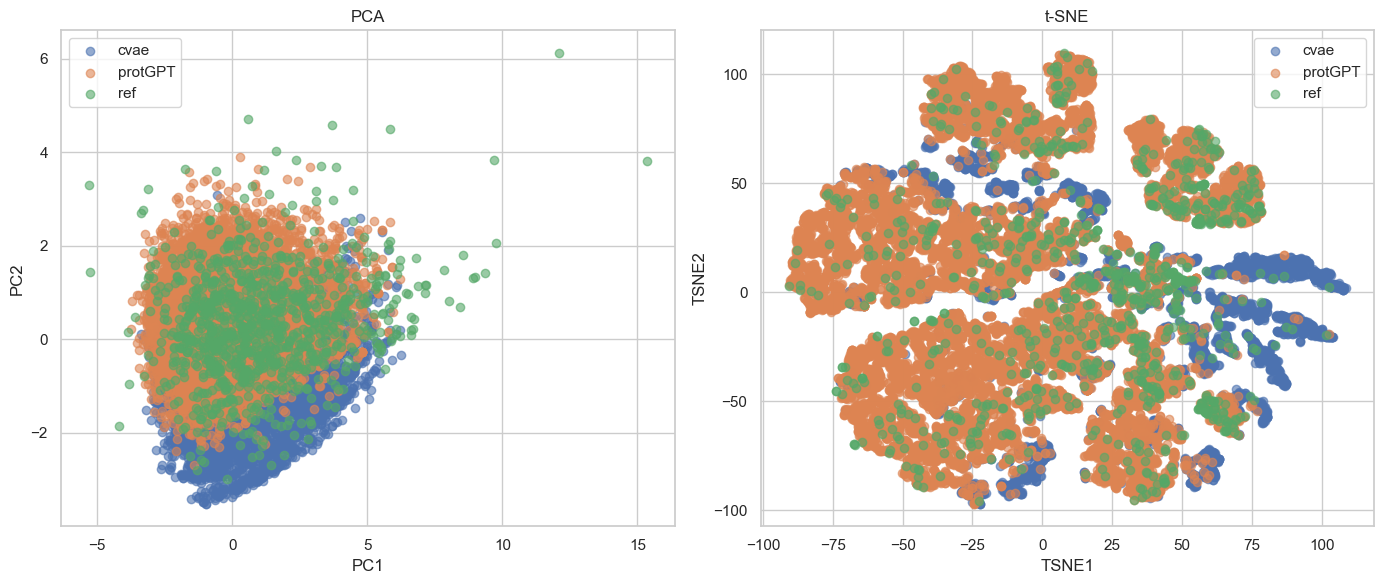

In [532]:
dfs = {
    "ref": df_ref,
    "cvae": df_cvae,
    "protGPT": df_protgpt,
}

feature_cols = [
    'beta_propensity',
    'proline_fraction',
    'AAT',
    'net_charge',
    'TA',
    'polar_fraction',
    'a3vSA'
]

plot_pca_tsne(dfs, feature_cols)

In [533]:
df_cvae.head()

,id,sequence,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA,length,...,lcc,beta_propensity_z,proline_fraction_z,AAT_z,net_charge_z,TA_z,polar_fraction_z,a3vSA_z,amyloid_likeness_score_norm,flag_outlier
0,CVAE_1,LHFGKHLDMEMM,12,0.039,0.459,-0.120,0.000,0,-1.2335,12,...,0.149373,-1.153614,-0.419245,-0.939255,-0.551173,0.036996,-1.922485,-0.021594,0.280950,False
1,CVAE_2,EGKFMW,6,0.137,1.181,-0.004,0.000,0,0.1853,6,...,0.215414,-1.117354,-0.419245,-0.635449,0.046247,0.362270,-1.922485,0.227867,0.347316,False
2,CVAE_3,LDFFW,5,0.818,2.291,0.408,2.291,1,1.8134,5,...,0.000000,1.064087,-0.419245,-0.168380,-0.700528,0.735528,-1.922485,1.961363,0.555848,False
4,CVAE_5,EWGFTM,6,0.266,1.172,0.130,0.000,0,0.8699,6,...,0.430827,-0.464662,-0.419245,-0.639236,-0.700528,0.519221,-0.870642,0.556238,0.306120,False
5,CVAE_6,MFGAED,6,-0.192,0.441,-0.342,0.000,0,-1.5073,6,...,0.430827,-2.190669,-0.419245,-0.946829,-1.447303,-0.025776,-1.922485,-0.609608,0.555151,False


In [534]:
df_protgpt.head()

,id,sequence,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA,length,...,lcc,beta_propensity_z,proline_fraction_z,AAT_z,net_charge_z,TA_z,polar_fraction_z,a3vSA_z,amyloid_likeness_score_norm,flag_outlier
0,ProtGPT2_1,LFFEDVN,7,0.276,1.715,-0.060,0.000,0,-0.0783,7,...,0.000000,0.071996,-0.419245,-0.410751,-1.447303,0.301837,-1.020905,0.581693,0.292230,False
1,ProtGPT2_2,GDRSRVFIGNV,11,-0.020,3.192,-0.072,3.192,1,-0.0885,11,...,0.223585,0.103641,-0.419245,0.210747,0.793022,0.299498,-0.775020,-0.171779,0.159417,False
2,ProtGPT2_3,VQIINNIRDITKDEVTQHFTVHNGNV,26,-0.099,3.342,-0.167,0.000,0,-3.8085,26,...,0.270132,0.553983,-0.419245,0.273864,-0.551173,-0.553349,0.262112,-0.372875,0.129453,False
4,ProtGPT2_5,GRYSFVIQGRDFS,13,0.068,3.582,-0.022,3.582,1,0.4799,13,...,0.207726,0.065301,-0.419245,0.374852,0.793022,0.429810,0.019379,0.052226,0.116591,False
5,ProtGPT2_6,TGNFLINQNFAEDA,14,-0.174,1.886,-0.188,0.000,0,-1.7417,14,...,0.472479,-0.661505,-0.419245,-0.338797,-1.447303,-0.079514,0.331465,-0.563789,0.202656,False


In [535]:
df_ref.head()

,id,sequence,length,class,merge_id,a3vSA,AAT,Na4vSS,THSA,nHS,...,hydrophobicity,polar_fraction,nonpolar_fraction,acidic_fraction,basic_fraction,aromatic_fraction,beta_propensity,seq_entropy,proline_fraction,lcc
0,GI_171848907_PDB_2RNM_A__1_1,GRNSAKDIRTEERARVQLGNV,21,1,GI_171848907_PDB_2RNM_A__1_1_0,-0.457,0.190,-0.494,0.190,1.0,...,-1.185714,0.238095,0.380952,0.142857,0.238095,0.000000,0.953333,3.535175,0.000000,0.427657
1,GI_342871650_GB_EGU74155_1_1,VRIYAKDIKSEEMARVRVGNE,21,1,GI_342871650_GB_EGU74155_1_1_0,-0.160,2.140,-0.165,1.871,1.0,...,-0.676190,0.142857,0.428571,0.190476,0.238095,0.047619,0.990000,3.427333,0.000000,0.266118
2,GI_342887385_GB_EGU86897_1_1,GKNSAGRINGPGMVNIGNS,19,1,GI_342887385_GB_EGU86897_1_1_0,-0.256,1.438,-0.256,1.438,1.0,...,-0.563158,0.315789,0.578947,0.000000,0.105263,0.000000,0.937368,3.005315,0.052632,0.365209
3,GI_347837243_EMB_CCD5181_1_1,HRIKIGKVTQASNAKAVIGVH,21,1,GI_347837243_EMB_CCD5181_1_1_0,-0.001,4.054,-0.008,4.054,2.0,...,-0.019048,0.190476,0.523810,0.000000,0.285714,0.000000,1.081429,3.296148,0.000000,0.466643
4,GI_475677570_GB_EMT74561_1_1,VRNYASEIKGDEDAKVRLGND,21,1,GI_475677570_GB_EMT74561_1_1_0,-0.436,0.570,-0.435,0.000,0.0,...,-1.138095,0.190476,0.380952,0.238095,0.190476,0.047619,0.912381,3.499228,0.000000,0.323078


## Redundancy

In [536]:
df_protgpt = df_protgpt.dropna(subset=["sequence"]).reset_index(drop=True)
df_cvae = df_cvae.dropna(subset=["sequence"]).reset_index(drop=True)

In [537]:
print("Before dropping duplicates:\nProtGPT:")
print(len(df_protgpt))
print("cVAE:")
print(len(df_cvae))

Before dropping duplicates:
ProtGPT:
13695
cVAE:
3800


In [538]:
df_protgpt = df_protgpt.drop_duplicates(subset="sequence")
df_cvae = df_cvae.drop_duplicates(subset="sequence")

In [539]:
print("After dropping duplicates:\nProtGPT:")
print(len(df_protgpt))
print("cVAE:")
print(len(df_cvae))

After dropping duplicates:
ProtGPT:
13140
cVAE:
3759


### MMseqs2

In [540]:
def write_fasta(df, filename, seq_col="sequence", id_col="id"):
    with open(filename, "w") as f:
        for _, row in df.iterrows():
            sid = row.get(id_col, "gen")
            seq = row[seq_col]
            f.write(f">{sid}\n{seq}\n")

In [541]:
write_fasta(df_protgpt, "./files/data/protgpt.fasta")
write_fasta(df_cvae, "./files/data/cvae.fasta")

In [542]:
write_fasta(df_ref, "./files/data/ref.fasta")

In [543]:
def read_fasta_to_df(path):
    records = []
    seq_id = None
    seq_chunks = []

    with open(path, "r") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            # header
            if line.startswith(">"):
                if seq_id is not None:
                    records.append({
                        "id": seq_id,
                        "sequence": "".join(seq_chunks)
                    })

                seq_id = line[1:].split()[0]  # clean ID
                seq_chunks = []

            else:
                seq_chunks.append(line)

        # last record
        if seq_id is not None:
            records.append({
                "id": seq_id,
                "sequence": "".join(seq_chunks)
            })

    return pd.DataFrame(records)

In [544]:
df_protgpt_nr = read_fasta_to_df("./files/data/protgpt_cluster_rep_seq.fasta")

In [545]:
print(len(df_protgpt_nr))
print(df_protgpt_nr.head())

11203
              id                         sequence
0  ProtGPT2_3295  TSNVTQIHDVNHSYGPVADVGNNTFHIGGAA
1  ProtGPT2_3296                      GNQTNQNIGNV
2  ProtGPT2_3298  GNTFTGQNYQGDNYSRVYQNGDNSTVHIGDH
3  ProtGPT2_3299          GTVWSFYLLYYDDTGDQTQHNTF
4  ProtGPT2_3301               GGNVAGDVNISGHGRVYV


In [546]:
df_cvae_nr = read_fasta_to_df("./files/data/cvae_cluster_rep_seq.fasta")
print(len(df_cvae_nr))
print(df_cvae_nr.head())

3694
          id      sequence
0  CVAE_1683         GEWAM
1  CVAE_1686     GNMFHMRKG
2  CVAE_1687       LWEDGIA
3  CVAE_1688    GMIMEWMFMY
4  CVAE_1689  GEWSHMEWEGMA


In [547]:
df_protgpt_nr = df_protgpt_nr.merge(
    df_protgpt,
    on="id",
    how="left",
    suffixes=("", "_gpt")
)

df_protgpt_nr = df_protgpt_nr.sort_values("id").reset_index(drop=True)

df_good_protgpt.head()

,id,sequence,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA,length,...,lcc,beta_propensity_z,proline_fraction_z,AAT_z,net_charge_z,TA_z,polar_fraction_z,a3vSA_z,amyloid_likeness_score_norm,flag_outlier
0,ProtGPT2_1,LFFEDVN,7,0.276,1.715,-0.060,0.000,0,-0.0783,7,...,0.000000,0.071996,-0.419245,-0.410751,-1.447303,0.301837,-1.020905,0.581693,0.292230,False
1,ProtGPT2_2,GDRSRVFIGNV,11,-0.020,3.192,-0.072,3.192,1,-0.0885,11,...,0.223585,0.103641,-0.419245,0.210747,0.793022,0.299498,-0.775020,-0.171779,0.159417,False
2,ProtGPT2_3,VQIINNIRDITKDEVTQHFTVHNGNV,26,-0.099,3.342,-0.167,0.000,0,-3.8085,26,...,0.270132,0.553983,-0.419245,0.273864,-0.551173,-0.553349,0.262112,-0.372875,0.129453,False
4,ProtGPT2_5,GRYSFVIQGRDFS,13,0.068,3.582,-0.022,3.582,1,0.4799,13,...,0.207726,0.065301,-0.419245,0.374852,0.793022,0.429810,0.019379,0.052226,0.116591,False
5,ProtGPT2_6,TGNFLINQNFAEDA,14,-0.174,1.886,-0.188,0.000,0,-1.7417,14,...,0.472479,-0.661505,-0.419245,-0.338797,-1.447303,-0.079514,0.331465,-0.563789,0.202656,False


In [548]:
df_cvae_nr = df_cvae_nr.merge(
    df_cvae,
    on="id",
    how="left",
    suffixes=("", "_cvae")
)

df_cvae_nr = df_cvae_nr.sort_values("id").reset_index(drop=True)

In [549]:
df_cvae_nr.head()

,id,sequence,sequence_cvae,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA,...,lcc,beta_propensity_z,proline_fraction_z,AAT_z,net_charge_z,TA_z,polar_fraction_z,a3vSA_z,amyloid_likeness_score_norm,flag_outlier
0,CVAE_1,LHFGKHLDMEMM,LHFGKHLDMEMM,12,0.039,0.459,-0.120,0.0,0,-1.2335,...,0.149373,-1.153614,-0.419245,-0.939255,-0.551173,0.036996,-1.922485,-0.021594,0.280950,False
1,CVAE_100,KFKHM,KFKHM,5,-0.046,0.000,-0.261,0.0,0,-0.9112,...,0.000000,-1.007121,-0.419245,-1.132395,1.614474,0.110886,-1.922485,-0.237963,0.513826,False
2,CVAE_10000,GKHGLF,GKHGLF,6,0.017,0.379,-0.312,0.0,0,-1.3569,...,0.264160,-0.928798,-0.419245,-0.972918,0.867699,0.008705,-1.922485,-0.077595,0.381566,False
3,CVAE_10004,WAEAIKMM,WAEAIKMM,8,0.283,1.631,0.073,0.0,0,0.7685,...,0.250000,-0.798260,-0.419245,-0.446097,0.046247,0.495974,-1.922485,0.599512,0.307389,False
4,CVAE_10005,MEFKRL,MEFKRL,6,0.077,0.000,-0.141,0.0,0,-0.6011,...,0.000000,-0.957807,-0.419245,-1.132395,0.793022,0.181980,-1.922485,0.075136,0.402461,False


## Reference data vs generated data

In [550]:
feature_cols = [
    'beta_propensity',
    'proline_fraction',
    'AAT',
    'net_charge',
    'TA',
    'polar_fraction',
    'a3vSA'
]

os.makedirs("figures", exist_ok=True)

datasets = {
    "REF": df_ref,
    "CVAE": df_cvae_nr,
    "PROTGPT2": df_protgpt_nr
}

palette = {
    "REF": "black",
    "CVAE": "blue",
    "PROTGPT2": "red"
}

sns.set(style="whitegrid")

In [551]:
def plot_feature_distributions():
    for feat in feature_cols:
        plt.figure(figsize=(8,5))

        for name, df in datasets.items():
            sns.kdeplot(df[feat], label=name, fill=True, alpha=0.3)

        plt.title(f"Distribution of {feat}")
        plt.legend()
        plt.tight_layout()
        #plt.savefig(f"figures/dist_{feat}.png", dpi=300)
        #plt.close()
        plt.show()

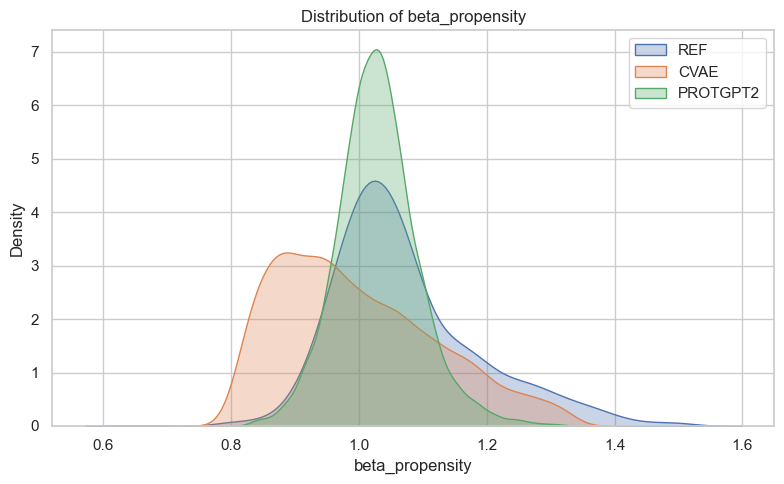

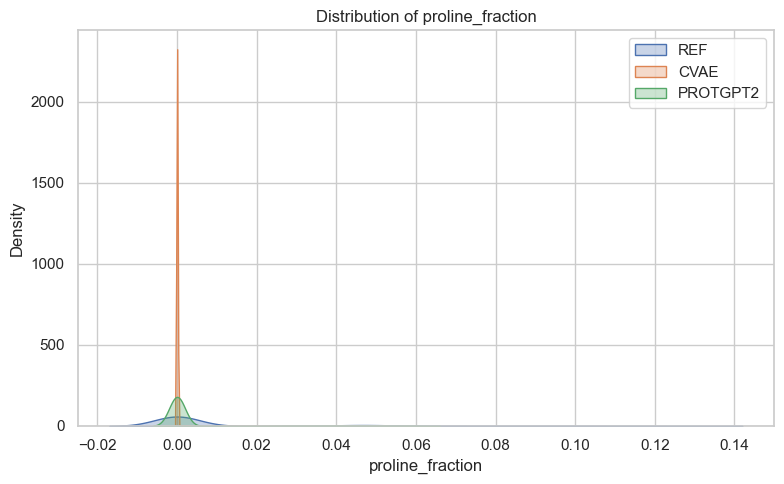

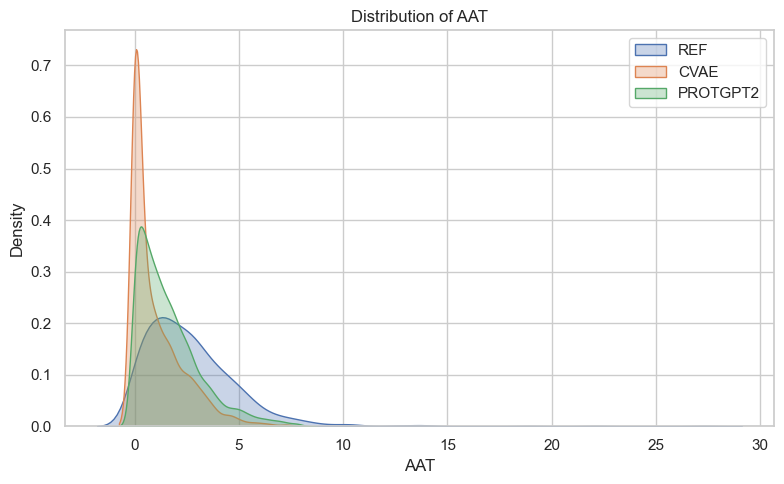

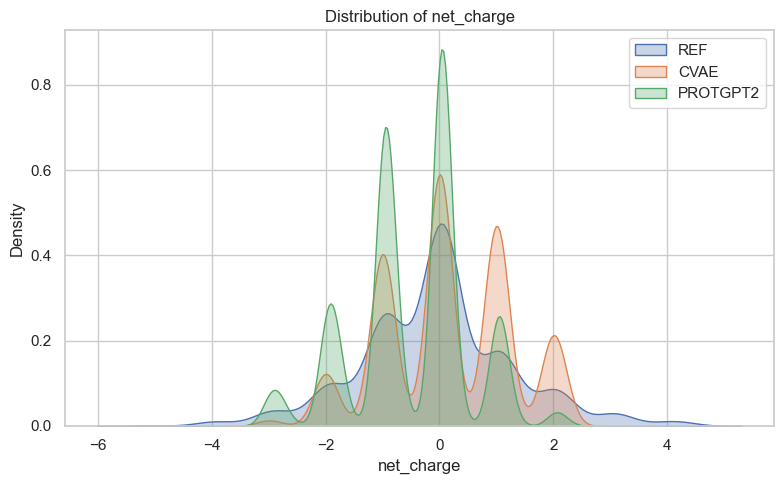

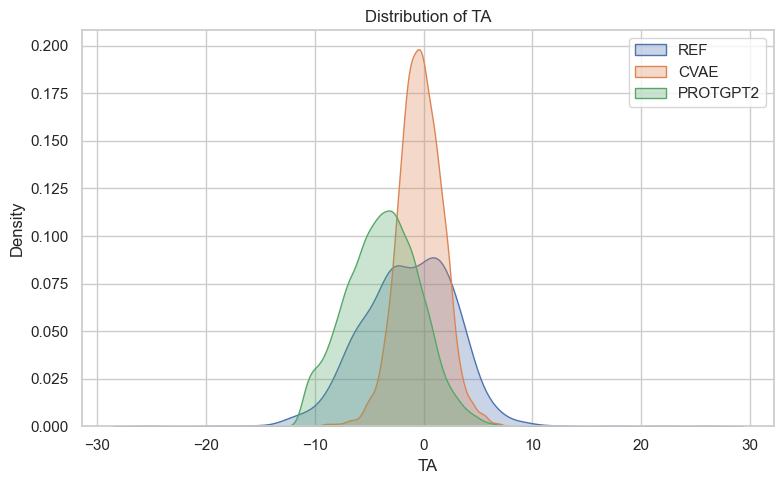

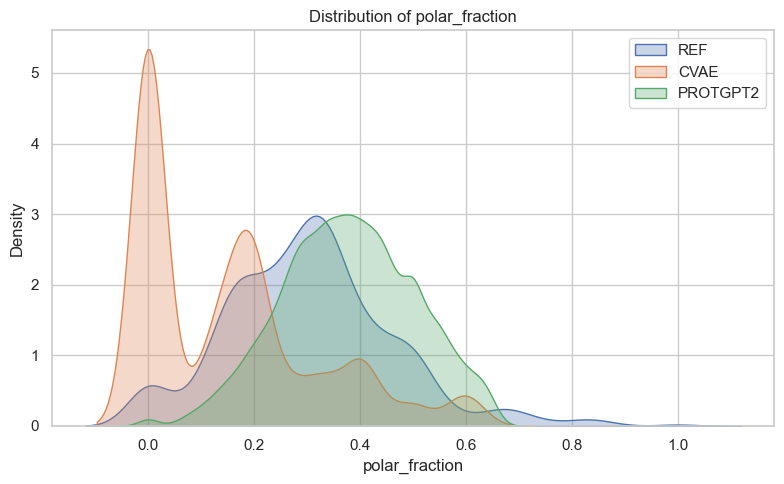

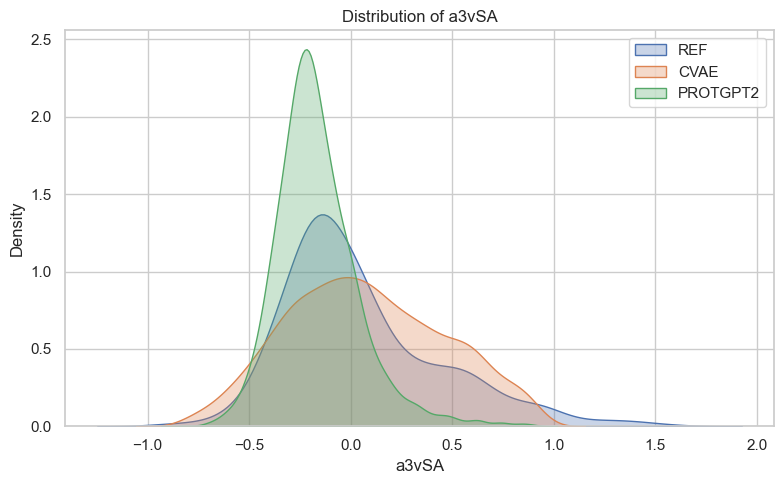

In [552]:
plot_feature_distributions()

In [553]:
def plot_boxplots():
    for feat in feature_cols:
        plt.figure(figsize=(8,5))

        data = []
        labels = []

        for name, df in datasets.items():
            data.extend(df[feat].values)
            labels.extend([name]*len(df))

        temp = pd.DataFrame({"value": data, "group": labels})

        sns.boxplot(x="group", y="value", data=temp, palette=palette)

        plt.title(f"Boxplot: {feat}")
        plt.tight_layout()
        #plt.savefig(f"figures/box_{feat}.png", dpi=300)
        #plt.close()
        plt.show()

C:\Users\marts\AppData\Local\Temp\ipykernel_9992\1093691133.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="group", y="value", data=temp, palette=palette)


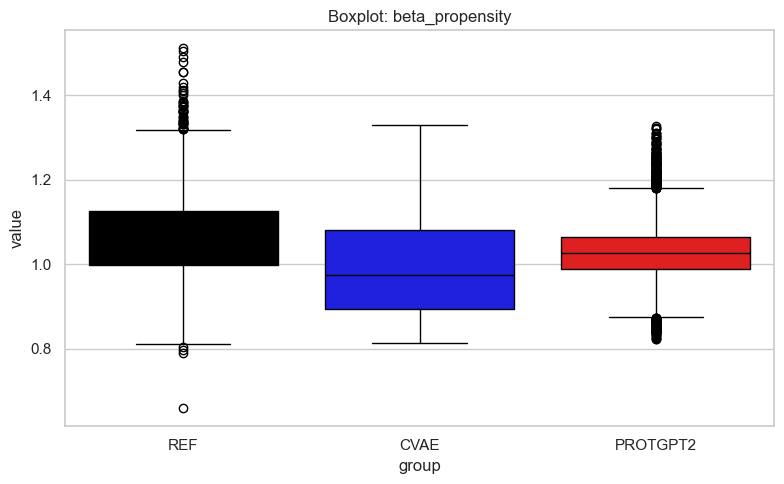

C:\Users\marts\AppData\Local\Temp\ipykernel_9992\1093691133.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="group", y="value", data=temp, palette=palette)


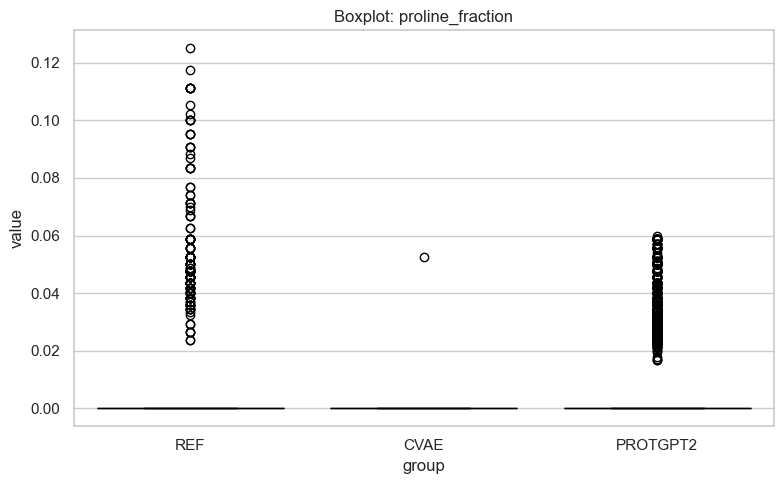

C:\Users\marts\AppData\Local\Temp\ipykernel_9992\1093691133.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="group", y="value", data=temp, palette=palette)


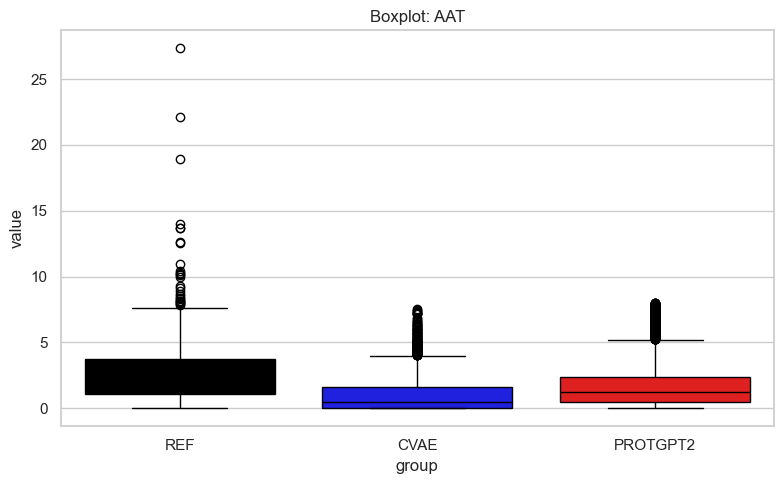

C:\Users\marts\AppData\Local\Temp\ipykernel_9992\1093691133.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="group", y="value", data=temp, palette=palette)


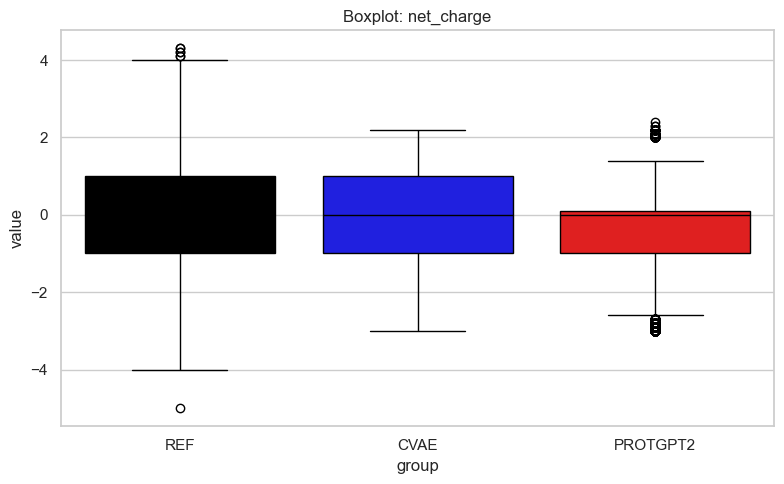

C:\Users\marts\AppData\Local\Temp\ipykernel_9992\1093691133.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="group", y="value", data=temp, palette=palette)


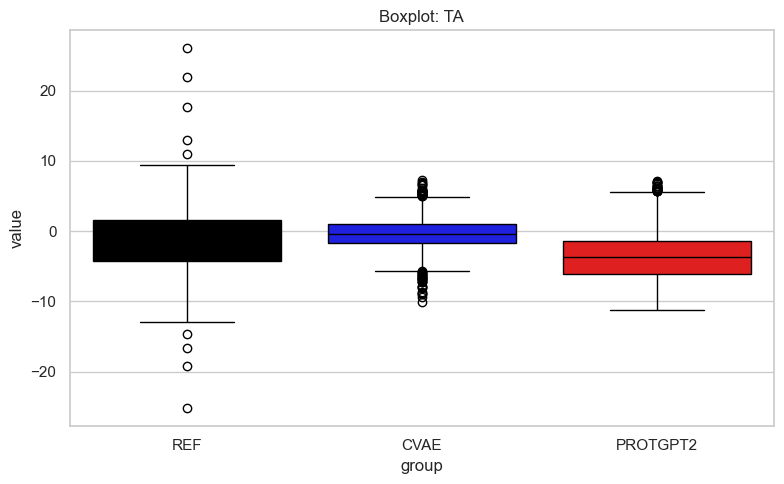

C:\Users\marts\AppData\Local\Temp\ipykernel_9992\1093691133.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="group", y="value", data=temp, palette=palette)


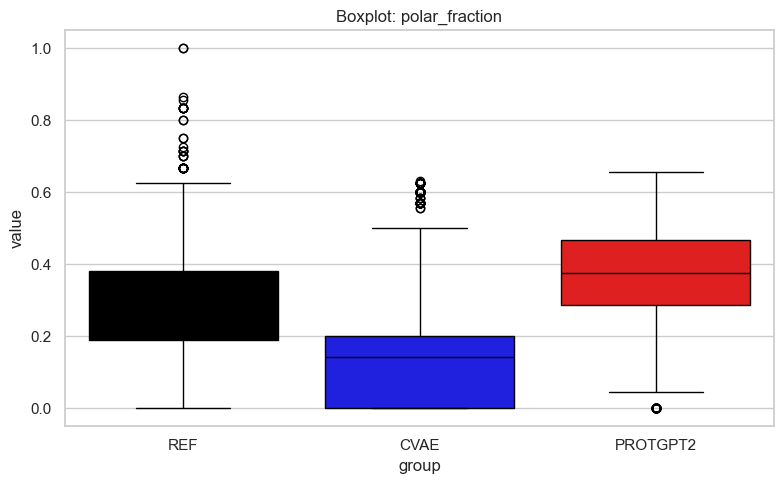

C:\Users\marts\AppData\Local\Temp\ipykernel_9992\1093691133.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="group", y="value", data=temp, palette=palette)


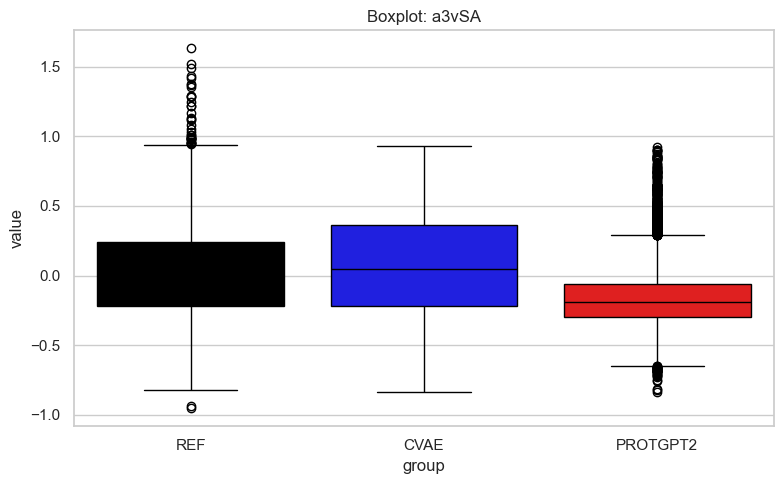

In [554]:
plot_boxplots()

In [555]:
def statistical_tests():
    results = []

    ref = df_ref

    for name, df in datasets.items():
        if name == "REF":
            continue

        for feat in feature_cols:
            ks = ks_2samp(ref[feat], df[feat])
            mw = mannwhitneyu(ref[feat], df[feat], alternative="two-sided")

            results.append({
                "feature": feat,
                "comparison": f"REF vs {name}",
                "KS_stat": ks.statistic,
                "KS_p": ks.pvalue,
                "MW_stat": mw.statistic,
                "MW_p": mw.pvalue
            })

    results_df = pd.DataFrame(results)
    print(results_df)
    #results_df.to_csv("figures/statistical_tests.csv", index=False)
    return results_df

In [556]:
stat_tests = statistical_tests()

             feature       comparison   KS_stat           KS_p    MW_stat  \
0    beta_propensity      REF vs CVAE  0.342342   7.523890e-83  2528397.0   
1   proline_fraction      REF vs CVAE  0.170703   1.339003e-20  2175231.0   
2                AAT      REF vs CVAE  0.416628  6.728233e-124  2868666.5   
3         net_charge      REF vs CVAE  0.125336   2.760254e-11  1768890.0   
4                 TA      REF vs CVAE  0.277775   2.799728e-54  1572763.5   
5     polar_fraction      REF vs CVAE  0.486432  4.991965e-171  2806002.0   
6              a3vSA      REF vs CVAE  0.119271   2.933640e-10  1722656.5   
7    beta_propensity  REF vs PROTGPT2  0.189592   1.586402e-29  6706834.5   
8   proline_fraction  REF vs PROTGPT2  0.088789   8.819884e-07  6070126.0   
9                AAT  REF vs PROTGPT2  0.237794   2.096537e-46  7335219.5   
10        net_charge  REF vs PROTGPT2  0.145206   1.900461e-17  6624542.5   
11                TA  REF vs PROTGPT2  0.277122   3.713124e-63  7588396.0   

In [557]:
def summarize_distribution_tests(results_df, alpha=0.05):
    print("=" * 80)
    print("DISTRIBUTION COMPARISON SUMMARY")
    print("=" * 80)

    comparisons = results_df["comparison"].unique()

    for comp in comparisons:

        print(f"\n### {comp}")
        print("-" * 80)

        sub = results_df[
            results_df["comparison"] == comp
        ].copy()

        sub = sub.sort_values("KS_stat", ascending=True)

        for _, row in sub.iterrows():

            feature = row["feature"]
            ks = row["KS_stat"]
            ks_p = row["KS_p"]
            mw_p = row["MW_p"]

            # interpretacja KS
            if ks < 0.10:
                similarity = "VERY SIMILAR"
            elif ks < 0.20:
                similarity = "MODERATELY SIMILAR"
            elif ks < 0.35:
                similarity = "DIFFERENT"
            else:
                similarity = "VERY DIFFERENT"

            # significance
            sig = (
                "SIGNIFICANT"
                if (ks_p < alpha and mw_p < alpha)
                else "NOT SIGNIFICANT"
            )

            print(
                f"{feature:<20}"
                f" KS={ks:.3f} | "
                f"{similarity:<20} | "
                f"{sig}"
            )

        # najbardziej podobne
        best = sub.iloc[0]

        # najbardziej różne
        worst = sub.iloc[-1]

        print("\nMost similar to reference:")
        print(
            f"  {best['feature']} "
            f"(KS={best['KS_stat']:.3f})"
        )

        print("\nMost different from reference:")
        print(
            f"  {worst['feature']} "
            f"(KS={worst['KS_stat']:.3f})"
        )

    print("\n" + "=" * 80)

    # global comparison
    print("\n### GLOBAL MODEL COMPARISON")
    print("-" * 80)

    model_scores = (
        results_df
        .groupby("comparison")["KS_stat"]
        .mean()
        .sort_values()
    )

    for comp, score in model_scores.items():
        print(f"{comp:<20} mean KS = {score:.3f}")

    best_model = model_scores.index[0]

    print(f"\nClosest overall to reference: {best_model}")

    print("=" * 80)

In [558]:
summarize_distribution_tests(stat_tests)

DISTRIBUTION COMPARISON SUMMARY

### REF vs CVAE
--------------------------------------------------------------------------------
a3vSA                KS=0.119 | MODERATELY SIMILAR   | SIGNIFICANT
net_charge           KS=0.125 | MODERATELY SIMILAR   | SIGNIFICANT
proline_fraction     KS=0.171 | MODERATELY SIMILAR   | SIGNIFICANT
TA                   KS=0.278 | DIFFERENT            | SIGNIFICANT
beta_propensity      KS=0.342 | DIFFERENT            | SIGNIFICANT
AAT                  KS=0.417 | VERY DIFFERENT       | SIGNIFICANT
polar_fraction       KS=0.486 | VERY DIFFERENT       | SIGNIFICANT

Most similar to reference:
  a3vSA (KS=0.119)

Most different from reference:
  polar_fraction (KS=0.486)

### REF vs PROTGPT2
--------------------------------------------------------------------------------
proline_fraction     KS=0.089 | VERY SIMILAR         | SIGNIFICANT
net_charge           KS=0.145 | MODERATELY SIMILAR   | SIGNIFICANT
beta_propensity      KS=0.190 | MODERATELY SIMILAR   | SIG

In [559]:
def plot_pca_tsne(dfs_dict, feature_cols, color_col=None, perplexity=30, random_state=42, figsize=(14, 6)):
    prepared = []

    for label, df in dfs_dict.items():
        df_ = df.copy()

        df_ = df_[feature_cols]

        df_ = df_.groupby(level=0, axis=1).mean()

        df_["source"] = label

        if color_col and color_col in df.columns:
            df_[color_col] = df[color_col].values

        prepared.append(df_)

    df_all = pd.concat(prepared, ignore_index=True)

    df_all = df_all.dropna(subset=feature_cols)

    X = df_all[feature_cols].values
    y = df_all["source"].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # tSNE
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=random_state)
    X_tsne = tsne.fit_transform(X_scaled)

    # plot
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # PCA
    for label in np.unique(y):
        idx = y == label
        axes[0].scatter(
            X_pca[idx, 0],
            X_pca[idx, 1],
            label=label,
            alpha=0.6
        )

    axes[0].set_title("PCA")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[0].legend()

    # t-SEN
    for label in np.unique(y):
        idx = y == label
        axes[1].scatter(
            X_tsne[idx, 0],
            X_tsne[idx, 1],
            label=label,
            alpha=0.6
        )

    axes[1].set_title("t-SNE")
    axes[1].set_xlabel("TSNE1")
    axes[1].set_ylabel("TSNE2")
    axes[1].legend()

    plt.tight_layout()
    #plt.savefig("./files/plots/generated_vs_ref_pca_tsne.svg", format="svg", bbox_inches="tight")
    plt.show()

C:\Users\marts\AppData\Local\Temp\ipykernel_9992\2843478847.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_ = df_.groupby(level=0, axis=1).mean()
C:\Users\marts\AppData\Local\Temp\ipykernel_9992\2843478847.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_ = df_.groupby(level=0, axis=1).mean()
C:\Users\marts\AppData\Local\Temp\ipykernel_9992\2843478847.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_ = df_.groupby(level=0, axis=1).mean()


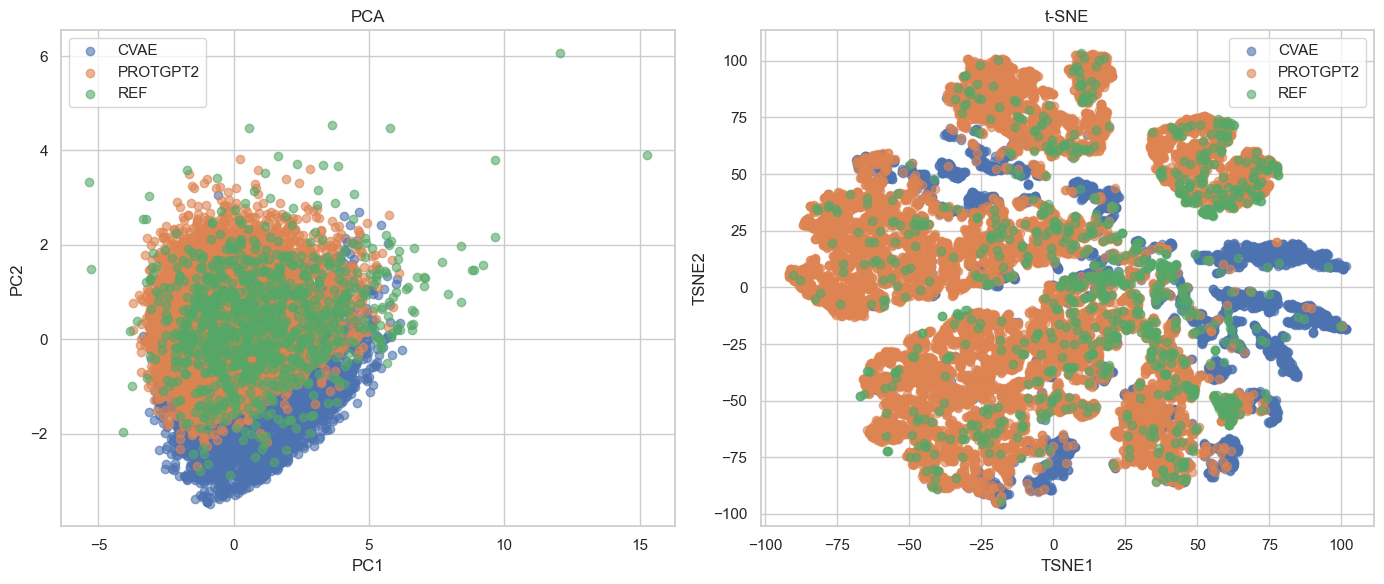

In [560]:
plot_pca_tsne(datasets, feature_cols)

<Axes: ylabel='Count'>

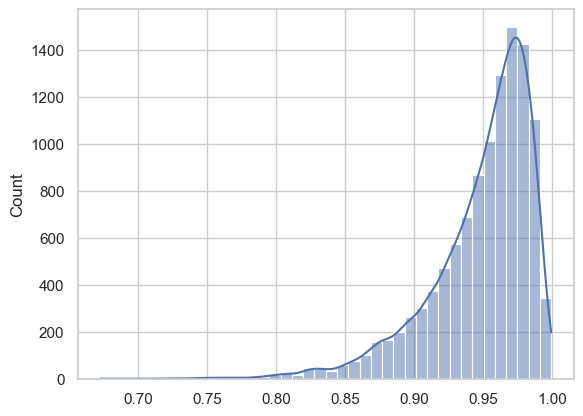

In [561]:
from sklearn.metrics.pairwise import cosine_similarity

ref = StandardScaler().fit_transform(df_ref[feature_cols])
syn = StandardScaler().fit_transform(df_protgpt_nr[feature_cols])

sim_matrix = cosine_similarity(syn, ref)

best_sim = sim_matrix.max(axis=1)

sns.histplot(best_sim, bins=40, kde=True)

<Axes: ylabel='Count'>

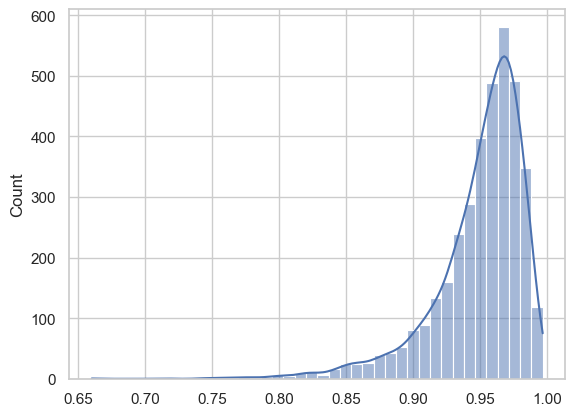

In [562]:
ref = StandardScaler().fit_transform(df_ref[feature_cols])
syn = StandardScaler().fit_transform(df_cvae_nr[feature_cols])

sim_matrix = cosine_similarity(syn, ref)

best_sim = sim_matrix.max(axis=1)

sns.histplot(best_sim, bins=40, kde=True)

In [563]:
def summary_table():
    rows = []

    for name, df in datasets.items():
        for feat in feature_cols:
            rows.append({
                "dataset": name,
                "feature": feat,
                "mean": df[feat].mean(),
                "std": df[feat].std(),
                "entropy": entropy(np.histogram(df[feat], bins=20, density=True)[0] + 1e-9)
            })

    df_out = pd.DataFrame(rows)
    print(df_out)
    #df_out.to_csv("figures/summary_stats.csv", index=False)

In [564]:
summary_table()

     dataset           feature      mean       std   entropy
0        REF   beta_propensity  1.071727  0.114909  2.306264
1        REF  proline_fraction  0.009457  0.022557  0.847437
2        REF               AAT  2.691157  2.376518  1.638181
3        REF        net_charge -0.061928  1.339091  2.014038
4        REF                TA -1.394870  4.361861  1.916669
5        REF    polar_fraction  0.304622  0.158452  2.428473
6        REF             a3vSA  0.047483  0.392848  2.409483
7       CVAE   beta_propensity  0.997404  0.124276  2.844824
8       CVAE  proline_fraction  0.000014  0.000866  0.002494
9       CVAE               AAT  1.007984  1.295060  1.922673
10      CVAE        net_charge  0.123308  1.129934  1.602303
11      CVAE                TA -0.331334  2.056013  2.279214
12      CVAE    polar_fraction  0.150005  0.167813  2.041540
13      CVAE             a3vSA  0.073689  0.385463  2.855477
14  PROTGPT2   beta_propensity  1.029165  0.064135  2.329974
15  PROTGPT2  proline_fr

## Final files

In [565]:
df_cvae_nr.to_csv(
    "./files/final_datasets/cvae_final.csv",
    index=False
)

In [566]:
df_protgpt_nr.to_csv(
    "./files/final_datasets/protgpt_final.csv",
    index=False
)